In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('../..'))
import torch
import sys
import geopandas as gpd
import pandas as pd
from matplotlib.patches import Patch

from notebooks.construct_dataset.shared_utils import assert_geodataframes_equal, sample_gdf, plot_aez_counts, get_new_random_seed

sys.path.append('./satclip/satclip')

from matplotlib import pyplot as plt
from dotenv import load_dotenv
import os

load_dotenv()
import random
import numpy as np

import shapely

try:
    RANDOM_SEED = int(os.environ["RANDOM_SEED"])
except:
    RANDOM_SEED = 15


random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)


torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

TRAIN_FOLDS = os.environ.get("TRAIN_FOLDS", [0,1,2])
VALID_FOLDS = os.environ.get("VALID_FOLDS", [3])
TEST_FOLDS = os.environ.get("TEST_FOLDS", [4])

AEZ_ROOT = os.getenv("AEZ_ROOT", "data/aez")
GPKGS_ROOT = os.getenv("GPKGS_ROOT", "data/gpkgs")

#parent_rng = np.random.default_rng(seed=RANDOM_SEED)

BASE_ASSET_PATH = os.environ.get("BASE_ASSET_PATH")

if BASE_ASSET_PATH.endswith(".parquet"):
    gdf = gpd.read_parquet(BASE_ASSET_PATH)
else:
    gdf = gpd.read_file(BASE_ASSET_PATH)
aez_number_to_class_label = {}
with open(f"../../{AEZ_ROOT}/AEZ_57classes.clr", "r") as infile:
    for line in infile:
        parts = line.strip().split()
        aez_number_to_class_label[int(parts[0])] = " ".join(parts[5:])

aez_number_to_class_label[0] = "Unclassified"

# def get_new_random_seed():
#     return parent_rng.integers(0,2**32)

In [2]:
gdf = gdf[gdf["tile"] != -1]
len(pd.unique(gdf["tile"]))

30

In [3]:
print(len(gdf))
value_counts = gdf["tile"].value_counts()
if -1 in value_counts.index:
        value_counts = value_counts.drop(index=[-1])
mean_count = value_counts.mean()
threshold = 0#0.05 * mean_count
keep_tiles = list(value_counts[value_counts > threshold].index.values)
gdf = gdf[gdf["tile"].isin(keep_tiles)]
print(len(gdf))

495307
495307


In [4]:
value_pcts = gdf["tile"].value_counts().apply(lambda x: x / len(gdf))

In [5]:
child_rng = np.random.default_rng(get_new_random_seed())
child_rng.shuffle(keep_tiles)

tile_groups = {}
N_GROUPS = 5


groups = {
    i: keep_tiles[int((i * (len(keep_tiles)/ N_GROUPS))): int(((i+1) * (len(keep_tiles )/ N_GROUPS)))]for i in range(N_GROUPS)
}
groups

{0: [np.int64(28),
  np.int64(31),
  np.int64(12),
  np.int64(11),
  np.int64(4),
  np.int64(7)],
 1: [np.int64(0),
  np.int64(19),
  np.int64(34),
  np.int64(20),
  np.int64(17),
  np.int64(8)],
 2: [np.int64(15),
  np.int64(5),
  np.int64(16),
  np.int64(22),
  np.int64(9),
  np.int64(27)],
 3: [np.int64(29),
  np.int64(25),
  np.int64(1),
  np.int64(33),
  np.int64(21),
  np.int64(10)],
 4: [np.int64(35),
  np.int64(14),
  np.int64(26),
  np.int64(13),
  np.int64(6),
  np.int64(32)]}

<Axes: >

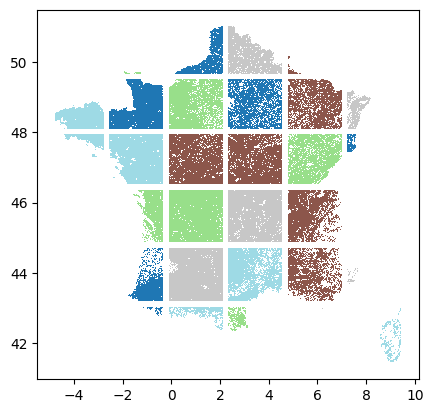

In [6]:
tile_groups = {
    i:groups[i] for i in range(len(groups))
}

reverse_tile_groups = {}

for g in tile_groups:
    vals = tile_groups[g]
    for v in vals:
        reverse_tile_groups[v] = g

cmap = plt.cm.tab20(np.linspace(0, 1, len(groups)))
group_assignments = [reverse_tile_groups[i] for i in gdf["tile"]]
gdf["tile_group"] = group_assignments

colors = [cmap[i] for i in gdf["tile_group"]]

gdf.plot(color=colors)

In [7]:
vcs = pd.Series(gdf["tile_group"]).value_counts().sort_index()
vcs

tile_group
0     75861
1    106159
2    136767
3     94553
4     81967
Name: count, dtype: int64

<BarContainer object of 5 artists>

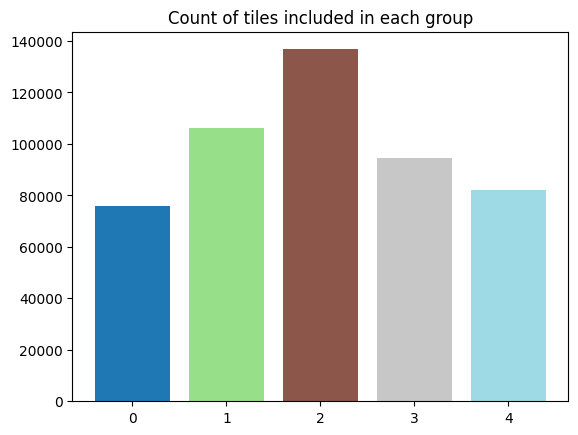

In [8]:
vcs = pd.Series(gdf["tile_group"]).value_counts().sort_index()
inds = list(vcs.index)
vals = list(vcs.values)
plt.title("Count of tiles included in each group")
plt.bar(x=inds, height=vals, color=[cmap[i] for i in inds])

In [9]:
gdf.columns

Index(['patch_i', 'patch_j', 'geometry', 'hedgerows', 'fold', 'tile',
       'aez_class', 'mst_class', 'thz_class', 'tile_group'],
      dtype='object')

In [10]:
gdf["fold"]

3         2
4         2
5         2
6        -1
7         3
         ..
603080    0
603081    0
603082    0
603083    0
603084    0
Name: fold, Length: 495307, dtype: int64

In [11]:
dataset = None

for size_group, n in zip(["small", "medium", "large"], [600,600,1200]):
    train_gdf = sample_gdf(gdf, TRAIN_FOLDS, split="train", n_per_fold=n)
    valid_gdf = sample_gdf(gdf, VALID_FOLDS,  split="valid", n_per_fold=n)
    test_gdf = sample_gdf(gdf, TEST_FOLDS, split="test", n_per_fold=n)

    curr_size_gdf = pd.concat([train_gdf, valid_gdf, test_gdf])
    curr_size_gdf["size_group"] = [size_group] * len(curr_size_gdf)

    if dataset is None:
        dataset = curr_size_gdf
    else:
        dataset = pd.concat([dataset, curr_size_gdf])

In [12]:
print(len(dataset[dataset["size_group"] == "small"]))
print(len(dataset[dataset["size_group"] == "medium"]))
print(len(dataset[dataset["size_group"] == "large"]))

2995
2995
6005


In [13]:
aez_class_subgroups = {
    "Sub-tropics, cool": [
        "Sub-tropics, cool; humid, no soil/terrain limitations",
        "Sub-tropics, cool; sub-humid, with soil/terrain limitations",
        "Sub-tropics, cool; sub-humid, no soil/terrain limitations",
    ],
    "Sub-tropics, mod.cool": [
        "Sub-tropics, mod. cool; humid, no soil/terrain limitations",
        "Sub-tropics, mod. cool; sub-humid, no soil/terrain limitations",
        "Sub-tropics, mod. cool; humid, with soil/terrain limitations",
        "Sub-tropics, mod. cool; sub-humid, with soil/terrain limitations"
    ],

    "Temperate, cool, moist": [
        "Temperate, cool; moist, no soil/terrain limitations",
        "Temperate, cool; moist, with soil/terrain limitations",
    ],

    "Temperate, cool, wet": [
        "Temperate, cool; wet, with soil/terrain limitations",
        "Temperate, cool; wet, no soil/terrain limitations",
    ],

    
    "Temperate, moderate": [
        "Temperate, moderate; moist, with soil/terrain limitations",
        "Temperate, moderate; moist, no soil/terrain limitations"
    ],

    "Terrain-dominated": [
        "Dominantly hydromorphic soils",
        "Dominantly very steep terrain",
        "Dominantly built-up land",
    ],

    "Misc": [
        "Ample irrigated soils",
        "Land with severe soil/terrain limitations",
        "Unclassified"
    ],
    
}

In [14]:
train_gdf = dataset[(dataset["size_group"] == "small") & (dataset["split"] == "train")]

for k in aez_class_subgroups:
    print(k)
    print(len(train_gdf[train_gdf["aez_class"].isin(aez_class_subgroups[k])]))

Sub-tropics, cool
140
Sub-tropics, mod.cool
89
Temperate, cool, moist
559
Temperate, cool, wet
710
Temperate, moderate
0
Terrain-dominated
62
Misc
171


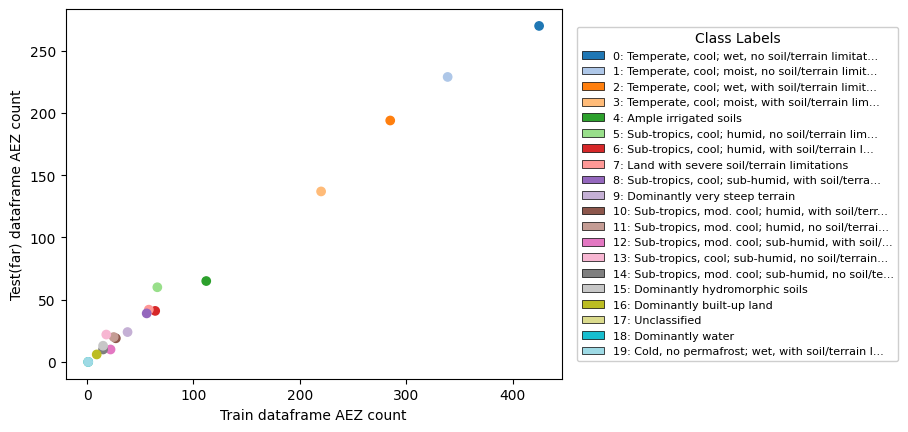

In [15]:
value_counts = train_gdf["aez_class"].value_counts().sort_values(ascending=False)
test_far_value_counts = test_gdf["aez_class"].value_counts().sort_index()
test_far_value_counts = test_far_value_counts.reindex(value_counts.index, fill_value=0)
colors = plt.cm.tab20(np.arange(len(value_counts)))
class_to_color = {class_name: colors[i] for i, class_name in enumerate(value_counts.index)}

plt.xlabel("Train dataframe AEZ count")
plt.ylabel("Test(far) dataframe AEZ count")
plt.scatter(x=value_counts, y=test_far_value_counts, c=colors)

legend_labels = [f"{i}: {str(label)[:45]}{'...' if len(str(label)) > 45 else ''}" 
                for i, label in enumerate(value_counts.index)]
legend_handles = [Patch(facecolor=colors[i], edgecolor='black', linewidth=0.5) 
                    for i in range(len(value_counts))]

plt.legend(legend_handles, legend_labels,
        loc='center left',
        bbox_to_anchor=(1.02, 0.5),
        fontsize=8,
        framealpha=0.95,
        title='Class Labels',
        title_fontsize=10,
        ncol=1)
plt.show()


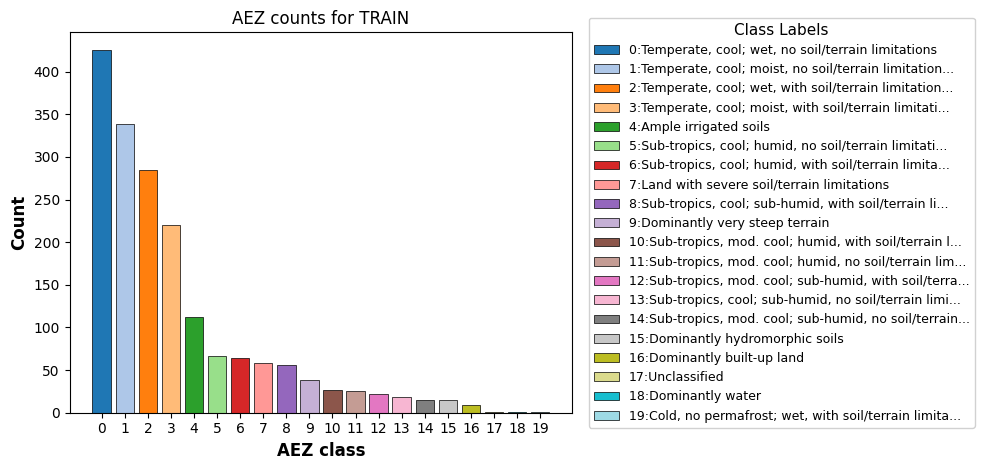

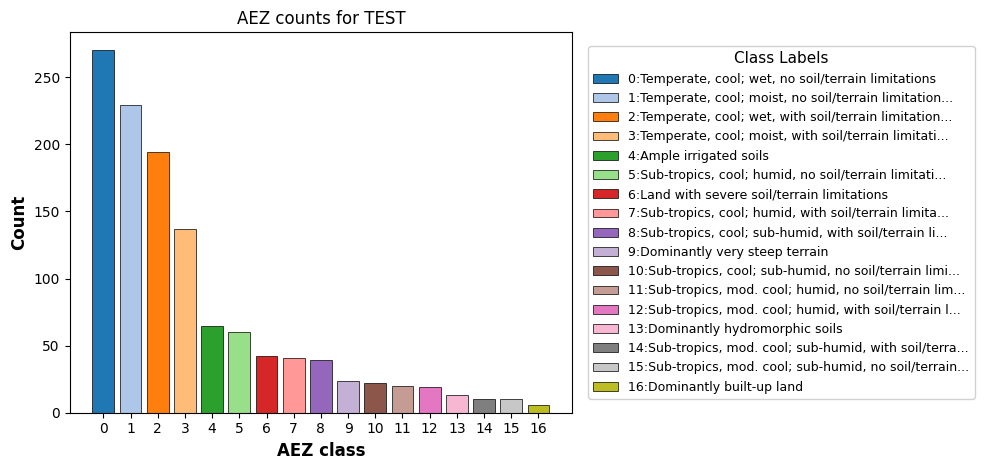

In [16]:

plot_aez_counts(train_gdf, colors=colors,title="AEZ counts for TRAIN")
plot_aez_counts(test_gdf, colors=colors,title="AEZ counts for TEST")


In [17]:
dataset["thz_class"].value_counts()

thz_class
TRC7: Temperate, cool                 9241
TRC5: Subtropics, cool                1749
TRC4: Subtropics, moderately cool      947
TRC8: Boreal / Cold, no permafrost      38
TRC6: Temperate, moderately cool        20
Name: count, dtype: int64

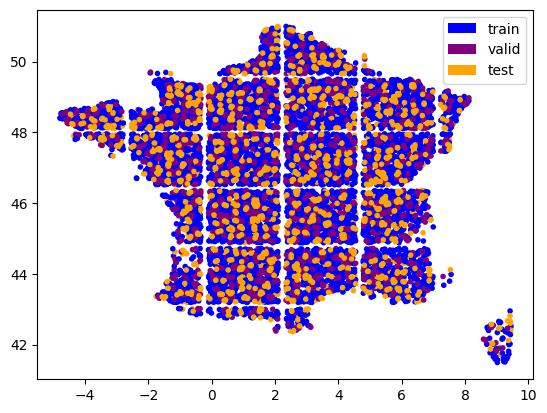

In [18]:
dataset = dataset.set_index(pd.RangeIndex(0,len(dataset)))
dataset["ID_PATCH"] = [i for i in range(len(dataset))]

xs = []
ys = []
colors = []

split_to_col = {
    "train": "blue",
    "valid": "purple",
    "test": "orange",
}

for i in range(len(dataset)):
    row = dataset.iloc[i]
    x,y = row.geometry.centroid.xy
    color = split_to_col[row["split"]]
    xs.append(x)
    ys.append(y)
    colors.append(color)

plt.scatter(x=xs, y=ys, c=colors, marker=".")
legend_elements = [Patch(facecolor=color, label=label) 
                   for label, color in split_to_col.items()]
plt.legend(handles=legend_elements)
plt.show()

In [19]:
dataset["ID_PATCH"]

0            0
1            1
2            2
3            3
4            4
         ...  
11990    11990
11991    11991
11992    11992
11993    11993
11994    11994
Name: ID_PATCH, Length: 11995, dtype: int64

In [20]:
SAVE_PATH = f"../../{GPKGS_ROOT}/hedgementation_dataset_1.3/initial_metadata.geojson"

previous_iteration = gpd.read_file(SAVE_PATH)
dataset_1point2 = gpd.read_file("../../data/gpkgs/hedgementation_dataset_1.2.gpkg")


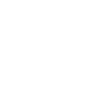

In [21]:
shapely.wkt.loads(dataset["hedgerows"].iloc[0])

In [22]:
for k in ["patch_i", "patch_j"]:
    if k in dataset.columns:
        dataset.drop(columns=k, inplace=True)
assert_geodataframes_equal(dataset, previous_iteration, geom_tol=1e-5)

In [23]:
for k in ['plot_color', 'quadrant', 'sixteenth']:
    if k in dataset_1point2:
        dataset_1point2.drop(columns=k, inplace=True)

assert_geodataframes_equal(dataset[dataset["size_group"] == "small"][dataset_1point2.columns], dataset_1point2, geom_tol=1e-5)

In [24]:
#dataset.to_file(SAVE_PATH)